In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
K_REFINED = 0 # None = all refinements; set e.g. 1 to truncate Bayesian after k-th refinement

In [3]:
LBFGS_SWEEP = 'convergence_w5_l_temp'
BAYESIAN_SWEEP = 'convergence_w5_b_temp'

In [4]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

In [5]:
def load_run(run_dir):
    for fname in ('results.json', 'checkpoint.json'):
        path = os.path.join(run_dir, fname)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            raw = json.load(f)
        methods = raw.get('methods', {})
        if not methods:
            return None
        method_name, inner = next(iter(methods.items()))
        d = dict(inner)
        d['method'] = method_name
        d['optimization_settings'] = raw.get('optimization_settings', {})
        d['source'] = fname
        d['elapsed'] = inner.get('time', float('nan'))
        return d
    return None

In [6]:
def discover_runs(base):
    runs = []
    for sweep in [LBFGS_SWEEP, BAYESIAN_SWEEP]:
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            print(f"not found: {sweep_dir}")
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

31 runs found
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:2/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.9414e-01  evals=1860  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.0527e-01  evals=1884  stop=exceeded wall time
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:4/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.7487e-09  evals=1050  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-01,lambda:1e-06,coils:5/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.8396e-02  evals=1911  stop=exceeded wall time
  convergence_w5_l_temp/alpha:1.0,weight:1e-02,lambda:1e-06,coils:2/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=1.6597e-01  evals=1275  stop=converged
  convergence_w5_l_temp/alpha:1.0,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=4.2089e-02  evals=1440 

In [7]:
rows = []
for r in runs:
    d = r['data']
    if 'cost_history' not in d:
        continue
    alpha = d.get('optimization_settings', {}).get('alpha', 0.75)
    total = np.array(d['cost_history'], dtype=float)
    flux_h = np.array([x if x is not None else np.nan for x in d.get('flux_err_history', [])], dtype=float)
    fb_h = np.array([x if x is not None else np.nan for x in d.get('fb_cost_history', [])], dtype=float)

    truncated = False
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', len(total))
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        if trunc > 0:
            total = total[:trunc]
            flux_h = flux_h[:trunc]
            fb_h = fb_h[:trunc]
            truncated = True
        t_bay = d.get('time_bayesian_phase', float('nan'))
        ref_times = d.get('refinement_times', [])
        elapsed_h = (t_bay + sum(ref_times[:min(K_REFINED, len(ref_times))])) / 3600
    else:
        elapsed_h = r['elapsed'] / 3600

    if len(total) == 0:
        continue

    if truncated:
        idx = int(np.nanargmin(total))
        best_flux = float(flux_h[idx]) if idx < len(flux_h) and np.isfinite(flux_h[idx]) else float(np.nanmin(flux_h))
        best_fb = float(fb_h[idx]) if idx < len(fb_h) and np.isfinite(fb_h[idx]) else float(np.nanmin(fb_h))
    else:
        best_flux = float(d.get('best_flux_err', float('nan')))
        best_fb = float(d.get('best_fb_cost', float('nan')))

    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'alpha': alpha,
        'best_cost_stored': float(np.nanmin(total)),
        'best_flux_err': best_flux,
        'best_fb_cost': best_fb,
        'init_fixed': float(d.get('initial_fixed_cost', float('nan'))),
        'init_fb': float(d.get('initial_fb_cost', float('nan'))),
        'fb_failures': r['fb_failures'],
        'n_evals': len(total),
        'elapsed_h': elapsed_h,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

# per weight_fb pair: norm = max(init_lbfgs, init_bayesian)
norm_df = df.groupby('weight_fb')[['init_fixed', 'init_fb']].max()
norm_df.columns = ['norm_fixed', 'norm_fb']
df = df.join(norm_df, on='weight_fb')

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / df['norm_fixed'] +
    df['alpha'] * df['best_fb_cost'] / df['norm_fb']
)

df = df.sort_values(['weight_fb', 'method'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

,sweep,method,weight_fb,num_coils,alpha,best_cost_stored,best_flux_err,best_fb_cost,init_fixed,init_fb,fb_failures,n_evals,elapsed_h,stopping,norm_fixed,norm_fb,best_cost_shared
27,convergence_w5_b_temp,Bayesian,1.0000e-04,2,1.0000e+00,1.3681e-01,1.7855e-02,2.1212e-03,5.3317e-02,1.5505e-02,3,89,9.6444e-01,all refinements completed,2.0760e-01,1.0000e+06,2.1212e-09
28,convergence_w5_b_temp,Bayesian,1.0000e-04,3,1.0000e+00,1.5789e-01,8.2208e-03,5.8567e-05,1.3629e-02,3.7093e-04,50,101,1.1318e+00,all refinements completed,2.0760e-01,1.0000e+06,5.8567e-11
29,convergence_w5_b_temp,Bayesian,1.0000e-04,4,1.0000e+00,2.2957e-01,6.6135e-03,7.3999e-05,1.0674e-02,3.2234e-04,49,126,1.4059e+00,all refinements completed,2.0760e-01,1.0000e+06,7.3999e-11
30,convergence_w5_b_temp,Bayesian,1.0000e-04,5,1.0000e+00,1.0973e-02,3.7397e-03,3.4704e-05,2.1516e-02,3.1626e-03,46,151,1.7604e+00,all refinements completed,2.0760e-01,1.0000e+06,3.4704e-11
12,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,2,1.0000e+00,1.8840e-01,1.9399e-01,3.3812e-03,1.4236e-01,1.7946e-02,10,1090,1.3456e+01,converged,2.0760e-01,1.0000e+06,3.3812e-09
13,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,3,1.0000e+00,2.7534e-02,1.9928e-02,7.9285e-04,2.0760e-01,2.8795e-02,62,1552,2.0064e+01,converged,2.0760e-01,1.0000e+06,7.9285e-10
14,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,4,1.0000e+00,1.3695e-10,5.2673e-03,1.3695e-04,2.1957e-02,1.0000e+06,44,924,1.1575e+01,converged,2.0760e-01,1.0000e+06,1.3695e-10
15,convergence_w5_l_temp,Multi-start L-BFGS,1.0000e-04,5,1.0000e+00,7.9609e-03,3.8671e-03,5.0580e-05,1.4111e-01,1.8836e-02,22,1457,2.0086e+01,converged,2.0760e-01,1.0000e+06,5.0580e-11
24,convergence_w5_b_temp,Bayesian,1.0000e-03,2,1.0000e+00,1.3384e-01,1.8557e-02,2.0752e-03,5.3317e-02,1.5505e-02,3,85,9.2748e-01,all refinements completed,2.0760e-01,1.0000e+06,2.0752e-09
25,convergence_w5_b_temp,Bayesian,1.0000e-03,3,1.0000e+00,1.5792e-01,8.2208e-03,5.8575e-05,1.3629e-02,3.7091e-04,79,101,1.1215e+00,all refinements completed,2.0760e-01,1.0000e+06,5.8575e-11


In [8]:
# run counts split by method
for method in sorted(df['method'].unique()):
    sub = df[df['method'] == method]
    piv = sub.groupby(['num_coils', 'weight_fb']).size().unstack(fill_value=0).astype(int)
    piv = piv.reindex(sorted(piv.columns), axis=1)
    piv.columns = [f'{c:.0e}' for c in piv.columns]
    print(method)
    display(piv)

Bayesian


,1e-04,1e-03,1e-02,1e-01
num_coils,,,,
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
5,1,0,1,1


Multi-start L-BFGS


,1e-04,1e-03,1e-02,1e-01
num_coils,,,,
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
5,1,1,1,1


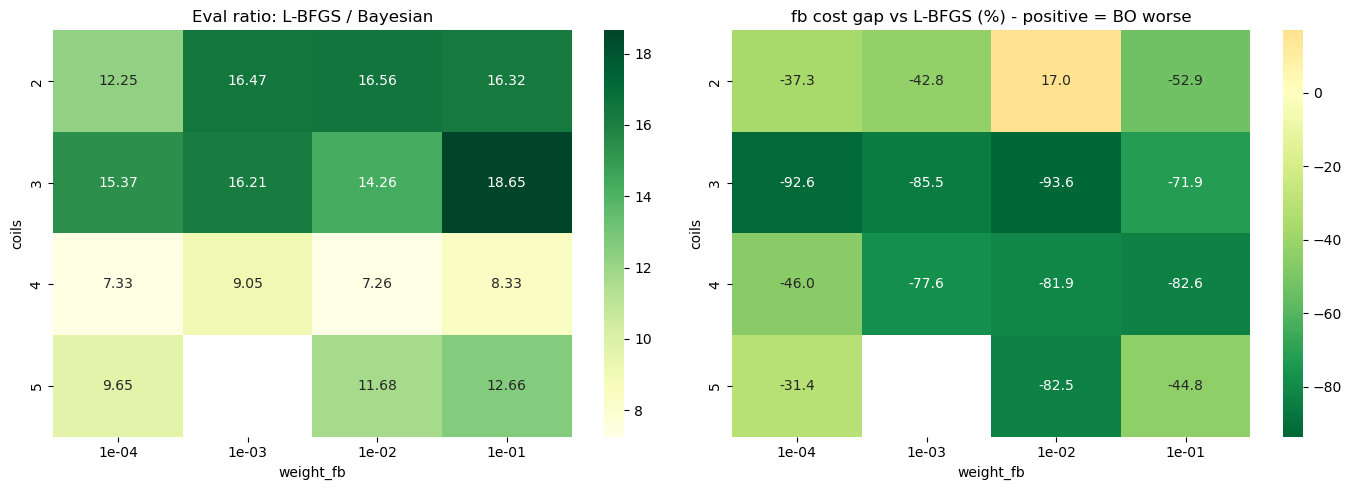

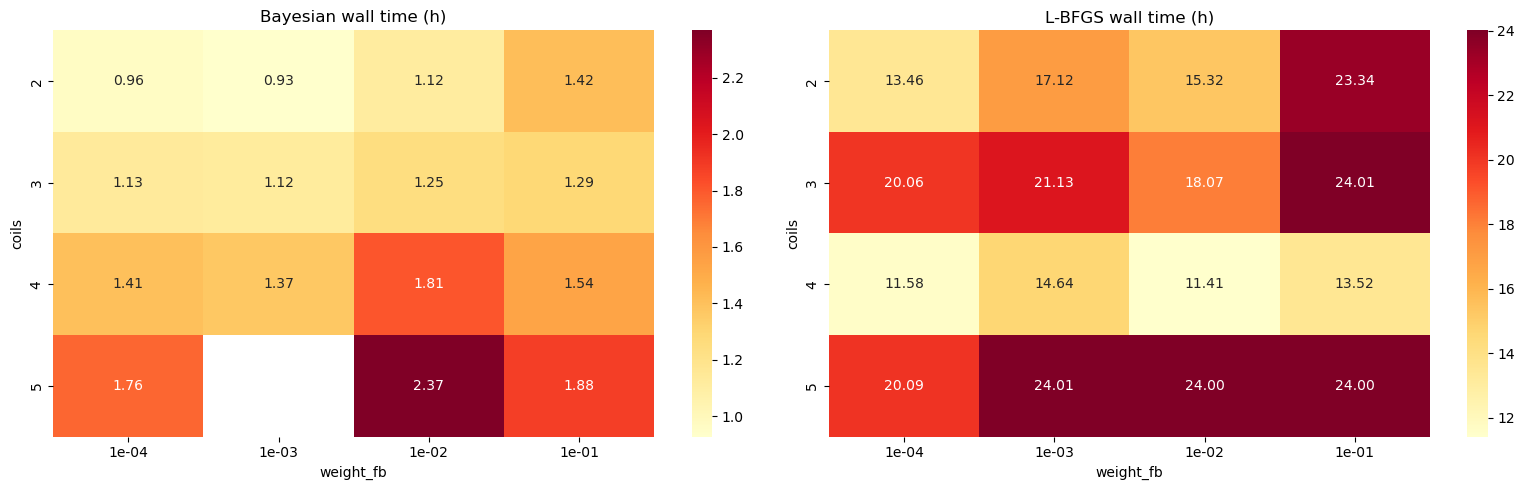

In [9]:
# bay vs lbfgs heatmaps across (coils x weight_fb) - mirrors bay_vs_lbfgs.ipynb style
# Gap measured on free-boundary cost (best_fb_cost) only.
best = df.sort_values('best_fb_cost').groupby(['num_coils', 'weight_fb', 'method'], sort=False).first().reset_index()

bay = best[best['method'] == 'Bayesian'].set_index(['num_coils', 'weight_fb'])
lbf = best[best['method'] != 'Bayesian'].set_index(['num_coils', 'weight_fb'])

cmp = pd.DataFrame(index=bay.index.union(lbf.index))
cmp['bayes_fb'] = bay['best_fb_cost']
cmp['lbfgs_fb'] = lbf['best_fb_cost']
cmp['bayes_evals'] = bay['n_evals']
cmp['lbfgs_evals'] = lbf['n_evals']
cmp['bayes_time_h'] = bay['elapsed_h']
cmp['lbfgs_time_h'] = lbf['elapsed_h']
cmp['fb_gap_lbfgs'] = (cmp['bayes_fb'] - cmp['lbfgs_fb']) / cmp['lbfgs_fb'] * 100
cmp['eval_ratio'] = cmp['lbfgs_evals'] / cmp['bayes_evals']
cmp = cmp.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, fmt in [
    (axes[0], 'eval_ratio', 'Eval ratio: L-BFGS / Bayesian', '.2f'),
    (axes[1], 'fb_gap_lbfgs', 'fb cost gap vs L-BFGS (%) - positive = BO worse', '.1f'),
]:
    pivot = cmp.pivot_table(index='num_coils', columns='weight_fb', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot.columns = [f'{c:.0e}' for c in pivot.columns]
    cmap = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('coils')
plt.tight_layout()
plt.show()

# timing heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mcol, title in [
    (axes[0], 'bayes_time_h', 'Bayesian wall time (h)'),
    (axes[1], 'lbfgs_time_h', 'L-BFGS wall time (h)'),
]:
    pivot = cmp.pivot_table(index='num_coils', columns='weight_fb', values=mcol)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot.columns = [f'{c:.0e}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('coils')
plt.tight_layout()
plt.show()

per-refinement breakdown:


,num_coils,weight_fb,refinement,best_gp,best_after_ref,step_improve_pct,cumulative_improve_pct,n_evals_in_ref
0,2,1.0000e-01,1,1.6534e-01,1.6534e-01,0.0000e+00,0.0000e+00,135
1,2,1.0000e-01,2,1.6534e-01,1.6534e-01,0.0000e+00,0.0000e+00,105
2,2,1.0000e-01,3,1.6534e-01,1.6534e-01,0.0000e+00,0.0000e+00,205
3,3,1.0000e-01,1,5.5275e-01,5.5275e-01,0.0000e+00,0.0000e+00,126
4,3,1.0000e-01,2,5.5275e-01,5.5275e-01,0.0000e+00,0.0000e+00,105
5,3,1.0000e-01,3,5.5275e-01,5.5275e-01,0.0000e+00,0.0000e+00,105
6,4,1.0000e-01,1,1.7407e-01,1.7407e-01,0.0000e+00,0.0000e+00,180
7,4,1.0000e-01,2,1.7407e-01,1.7407e-01,0.0000e+00,0.0000e+00,171
8,4,1.0000e-01,3,1.7407e-01,1.7407e-01,0.0000e+00,0.0000e+00,126
9,5,1.0000e-01,1,7.2033e-02,7.2033e-02,0.0000e+00,0.0000e+00,198


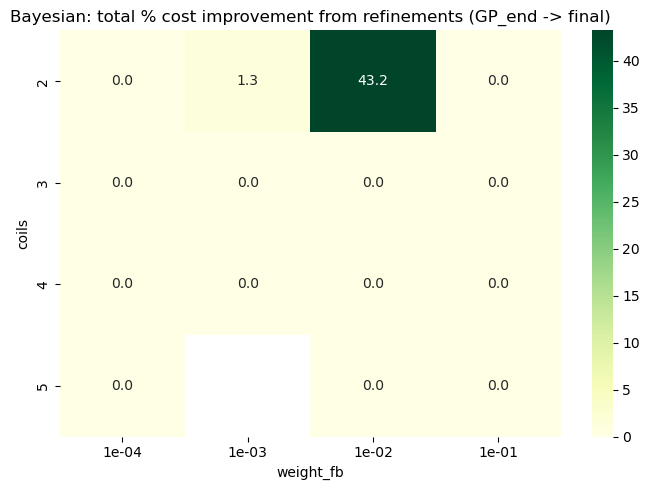

In [17]:
# bayesian refinement improvement: % cost reduction from end of GP phase to end of each refinement
ref_rows = []
for r in runs:
    if r['method'] != 'Bayesian':
        continue
    d = r['data']
    total = np.array(d['cost_history'], dtype=float)
    n_bay = d.get('n_bayesian_evals', 0)
    ref_evals = d.get('refinement_evals', []) or []
    if n_bay == 0 or len(total) <= n_bay:
        continue
    best_gp = float(np.nanmin(total[:n_bay]))
    cum = n_bay
    cum_best = best_gp
    for i, re in enumerate(ref_evals):
        prev_best = cum_best
        cum += re
        cum_best = float(np.nanmin(total[:cum]))
        step_improve = (prev_best - cum_best) / prev_best * 100 if prev_best > 0 else float('nan')
        cumulative_improve = (best_gp - cum_best) / best_gp * 100 if best_gp > 0 else float('nan')
        ref_rows.append({
            'num_coils': r['num_coils'],
            'weight_fb': r['weight_fb'],
            'refinement': i + 1,
            'best_gp': best_gp,
            'best_after_ref': cum_best,
            'step_improve_pct': step_improve,
            'cumulative_improve_pct': cumulative_improve,
            'n_evals_in_ref': re,
        })

ref_df = pd.DataFrame(ref_rows)
print('per-refinement breakdown:')
display(ref_df)

# total improvement per (coils, weight_fb): last refinement
total_imp = ref_df.sort_values('refinement').groupby(['num_coils', 'weight_fb']).last().reset_index()

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
piv_total = total_imp.pivot_table(index='num_coils', columns='weight_fb', values='cumulative_improve_pct')
piv_total = piv_total.reindex(sorted(piv_total.columns), axis=1)
piv_total.columns = [f'{c:.0e}' for c in piv_total.columns]
sns.heatmap(piv_total, annot=True, fmt='.1f', cmap='YlGn', ax=axes)
axes.set_title('Bayesian: total % cost improvement from refinements (GP_end -> final)')
axes.set_xlabel('weight_fb')
axes.set_ylabel('coils')

plt.tight_layout()
plt.show()
